In [1]:
import matplotlib.pyplot as plt
from matplotlib import gridspec
import numpy as np
import os
import pandas as pd
import pickle
import seaborn as sns
import yaml
import torch
from daart.data import DataGenerator, compute_sequence_pad
from daart.eval import get_precision_recall, run_lengths
from daart.io import get_expt_dir, find_experiment
from daart.transforms import ZScore
from daart_utils.data import DataHandler
from daart_utils.models import compute_model_predictions, get_default_hparams
from daart_utils.plotting import plot_heatmaps
from daart.models import Segmenter

In [2]:
def confusion_matrix(true_states, inf_states, num_states):
    confusion = np.zeros((num_states, num_states))
    ztotal = np.zeros((num_states, 1))
    for i in range(num_states):
        for ztrue, zinf in zip(true_states, inf_states):
            for j in range(num_states):
                confusion[i, j] += np.sum((ztrue == i) & (zinf == j))
            ztotal[i] += np.sum(ztrue==i)
    return confusion / ztotal

def get_framewise_f1(pred, true, n):
    
    res = []

    for i in range(1, n+1):
        pos_temp = np.zeros_like(true)
        pos_temp[np.where(true==i)] = 1
        
        pred_temp = np.zeros_like(pred)
        pred_temp[np.where(pred==i)] = 1
        
        metrics = {}
        tp = 0
        fp = 0
        fn = 0
        tn = 0
        
        for t, p in zip(pos_temp, pred_temp):
            if t == 1 and p == 1:
                tp+=1
            elif t == 0 and p == 1:
                fp+=1
            elif t == 1 and p ==0:
                fn+=1
            else:
                tn+=1
        
        metrics['tp'] = tp
        metrics['fp'] = fp
        metrics['fn'] = fn
        metrics['n'] = tp+fn
        
        res.append(metrics)
        
    return res
    

In [3]:
label_names = ['background', 'still', 'move', 'wheel_turn', 'groom']
dataset = 'ibl'

# load model

## change this to where you store the model and haparm files
model_dir = "/home/bsb2144/daart/results_daart/ibl/multi-0/dtcn/ibl_tcn8-5-good_sample-0_markers/version_0"

model_file = os.path.join(model_dir, 'last_model.pt')
arch_file = os.path.join(model_dir, 'hparams.yaml')

print('Loading model defined in %s' % arch_file)
with open(arch_file, 'rb') as f:
    hparams_new = yaml.safe_load(f)

input_type = hparams_new['input_type']
model_0 = Segmenter(hparams_new)

model_0.load_state_dict(torch.load(
    model_file, map_location=lambda storage, loc: storage))
model_0.to(hparams_new['device'])
model_0.eval()

Loading model defined in /home/bsb2144/daart/results_daart/ibl/multi-0/dtcn/ibl_tcn8-5-good_sample-0_markers/version_0/hparams.yaml


Segmenter(
  (model): ModuleDict(
    (encoder): DilatedTCN(
      (model): Sequential(
        (tcn_block_00): DilationBlock(
          (conv0): Conv1d(3, 32, kernel_size=(9,), stride=(1,), padding=(4,))
          (conv1): Conv1d(32, 32, kernel_size=(9,), stride=(1,), padding=(4,))
          (activation): LeakyReLU(negative_slope=0.05)
          (final_activation): LeakyReLU(negative_slope=0.05)
          (dropout): Dropout2d(p=0.1, inplace=False)
          (block): Sequential(
            (conv1d_layer_0): Conv1d(3, 32, kernel_size=(9,), stride=(1,), padding=(4,))
            (lrelu_0): LeakyReLU(negative_slope=0.05)
            (dropout_0): Dropout2d(p=0.1, inplace=False)
            (conv1d_layer_1): Conv1d(32, 32, kernel_size=(9,), stride=(1,), padding=(4,))
            (lrelu_1): LeakyReLU(negative_slope=0.05)
            (dropout_1): Dropout2d(p=0.1, inplace=False)
          )
          (downsample): Conv1d(3, 32, kernel_size=(1,), stride=(1,))
        )
        (tcn_block_01): 

churchlandlab_CSHL045_2020-02-27-001
NZ:  0
----------------------------
Generator contains 1 SingleDataset objects:
churchlandlab_CSHL045_2020-02-27-001
    signals: ['markers', 'labels_strong']
    transforms: OrderedDict([('markers', ZScore()), ('labels_strong', None)])
    paths: OrderedDict([('markers', '/home/bsb2144/daart_utils/data/ibl/markers/churchlandlab_CSHL045_2020-02-27-001_labeled.npy'), ('labels_strong', '/home/bsb2144/daart_utils/data/labels-hand/churchlandlab_CSHL045_2020-02-27-001_labels.csv')])

----------------------------


computing predictions for model 0...

/home/bsb2144/miniconda3/envs/daart2/lib/python3.7/site-packages/ipykernel_launcher.py:9: RuntimeWarning: invalid value encountered in true_divide
  if __name__ == "__main__":


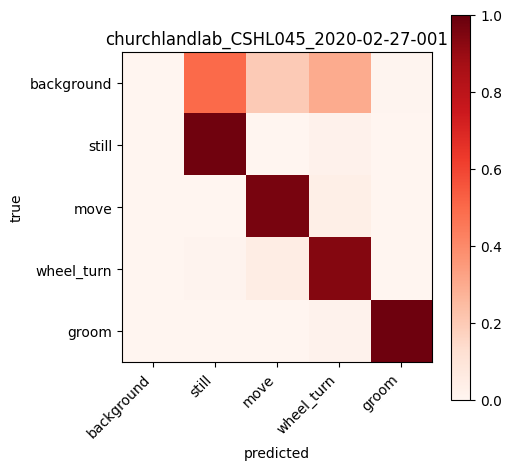

cortexlab_KS020_2020-02-06-001
NZ:  0
----------------------------
Generator contains 1 SingleDataset objects:
cortexlab_KS020_2020-02-06-001
    signals: ['markers', 'labels_strong']
    transforms: OrderedDict([('markers', ZScore()), ('labels_strong', None)])
    paths: OrderedDict([('markers', '/home/bsb2144/daart_utils/data/ibl/markers/cortexlab_KS020_2020-02-06-001_labeled.npy'), ('labels_strong', '/home/bsb2144/daart_utils/data/labels-hand/cortexlab_KS020_2020-02-06-001_labels.csv')])

----------------------------


computing predictions for model 0...

<Figure size 640x480 with 0 Axes>

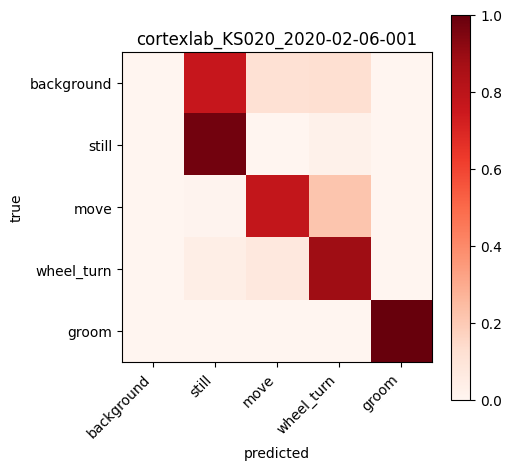

hoferlab_SWC_043_2020-09-15-001
NZ:  0
----------------------------
Generator contains 1 SingleDataset objects:
hoferlab_SWC_043_2020-09-15-001
    signals: ['markers', 'labels_strong']
    transforms: OrderedDict([('markers', ZScore()), ('labels_strong', None)])
    paths: OrderedDict([('markers', '/home/bsb2144/daart_utils/data/ibl/markers/hoferlab_SWC_043_2020-09-15-001_labeled.npy'), ('labels_strong', '/home/bsb2144/daart_utils/data/labels-hand/hoferlab_SWC_043_2020-09-15-001_labels.csv')])

----------------------------


computing predictions for model 0...

<Figure size 640x480 with 0 Axes>

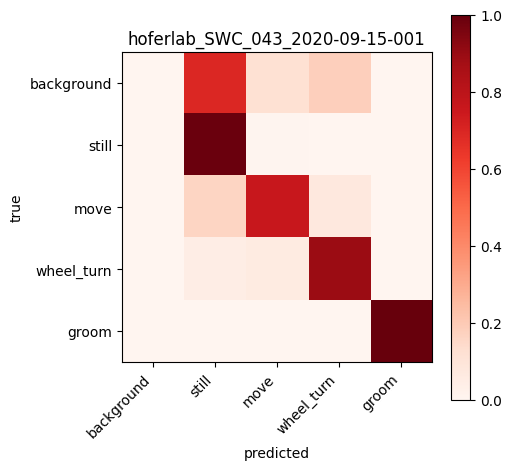

mrsicflogellab_SWC_052_2020-10-22-001
NZ:  0
----------------------------
Generator contains 1 SingleDataset objects:
mrsicflogellab_SWC_052_2020-10-22-001
    signals: ['markers', 'labels_strong']
    transforms: OrderedDict([('markers', ZScore()), ('labels_strong', None)])
    paths: OrderedDict([('markers', '/home/bsb2144/daart_utils/data/ibl/markers/mrsicflogellab_SWC_052_2020-10-22-001_labeled.npy'), ('labels_strong', '/home/bsb2144/daart_utils/data/labels-hand/mrsicflogellab_SWC_052_2020-10-22-001_labels.csv')])

----------------------------


computing predictions for model 0...

<Figure size 640x480 with 0 Axes>

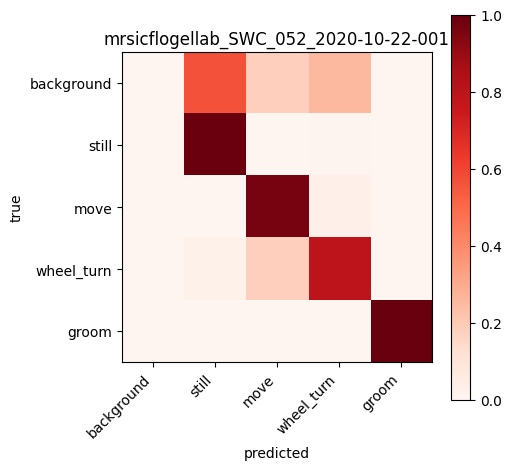

wittenlab_ibl_witten_27_2021-01-21-001
NZ:  0
----------------------------
Generator contains 1 SingleDataset objects:
wittenlab_ibl_witten_27_2021-01-21-001
    signals: ['markers', 'labels_strong']
    transforms: OrderedDict([('markers', ZScore()), ('labels_strong', None)])
    paths: OrderedDict([('markers', '/home/bsb2144/daart_utils/data/ibl/markers/wittenlab_ibl_witten_27_2021-01-21-001_labeled.npy'), ('labels_strong', '/home/bsb2144/daart_utils/data/labels-hand/wittenlab_ibl_witten_27_2021-01-21-001_labels.csv')])

----------------------------


computing predictions for model 0...

<Figure size 640x480 with 0 Axes>

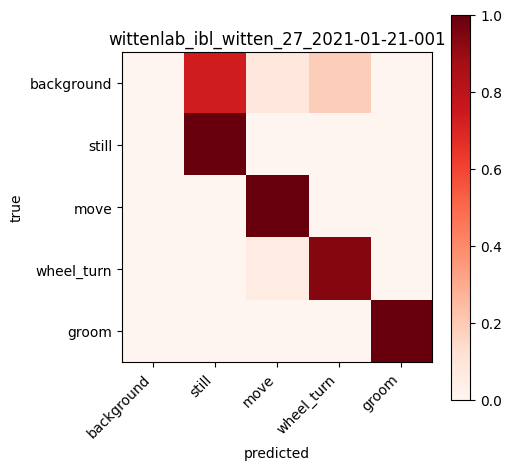

avg f1:  0.932
still f1: 0.965
move f1: 0.854
wheel_turn f1: 0.91
groom f1: 0.997


<Figure size 640x480 with 0 Axes>

In [4]:
# test data
data_path = '/home/bsb2144/daart_utils/data'
states_hand = {}
state_overlaps_0 = {}
states_0 = {}
state_overlaps = {}
n_vids = []
frame_f1 = []

sess_ids_test = [
    'churchlandlab_CSHL045_2020-02-27-001',
    'cortexlab_KS020_2020-02-06-001',
    'hoferlab_SWC_043_2020-09-15-001',
    'mrsicflogellab_SWC_052_2020-10-22-001',
    'wittenlab_ibl_witten_27_2021-01-21-001',
]
for expt_id in sess_ids_test:
        
    print(expt_id)
    
    # initialize data handler; point to correct base path
    handler = DataHandler(expt_id, base_path=os.path.join(data_path, dataset))
    if input_type == 'markers':
        markers_file = handler.get_marker_filepath()
    else:
        markers_file = handler.get_feature_filepath(dirname=input_type)

    hand_labels_file = os.path.join(
                data_path, 'labels-hand', expt_id + '_labels.csv')

    # define data generator signals
    signals = ['markers', 'labels_strong']
    transforms = [ZScore(), None]
    paths = [markers_file, hand_labels_file]

    # build data generator
    data_gen_test = DataGenerator(
        [expt_id], [signals], [transforms], [paths], device=hparams_new['device'], 
        batch_size=hparams_new['batch_size'], trial_splits='9;1;0;0', #'1;1;0;0', 
        sequence_pad=hparams_new['sequence_pad'], sequence_length=hparams_new['sequence_length'],
        input_type=hparams_new['input_type'])
    print('----------------------------')
    print(data_gen_test)
    print('----------------------------')
    print('\n')

    # load hand labels
    handler.load_hand_labels()
    states = np.argmax(handler.hand_labels.vals, axis=1)
    states_hand[expt_id] = states

    # compute predictions
    print('computing predictions for model 0...', end='')
    tmp = model_0.predict_labels(data_gen_test, return_scores=True)
    labels_pred = np.vstack(tmp['labels'][0])
    labels_model = np.argmax(labels_pred, axis=1)
    states_0[expt_id] = labels_model

    states = states[:len(labels_model)]
    states_hand[expt_id] = states
    temp = get_framewise_f1(states_0[expt_id][states > 0], states[states > 0], len(label_names)-1)
    frame_f1.append(temp)
    n_vids.append(len(states[states > 0]))

    state_overlaps_0[expt_id] = confusion_matrix(
        [states[states > 0]], [states_0[expt_id][states > 0]], num_states=len(label_names))
    states_all_hand = []
    states_all_0 = []
    
    s = states_hand[expt_id]
    states_all_hand.append(states_hand[expt_id])#[s > 0])
    states_all_0.append(states_0[expt_id])#[s > 0])

    state_overlaps_all_0 = confusion_matrix(
        states_all_hand, states_all_0, num_states=len(label_names))
    
    fig = plt.figure(figsize=(5, 5))
    im = plt.imshow(state_overlaps_all_0[:, :], vmin=0, vmax=1, cmap='Reds')#'Greys_r')
    plt.title(expt_id)
    plt.yticks(np.arange(len(label_names)), label_names[:])
    plt.ylabel('true')
    plt.xlabel('predicted')
    plt.xticks(np.arange(len(label_names)), label_names[:], rotation=45, ha='right')
    plt.colorbar()
    plt.show()
    plt.figure()


# Framewise F1
res = []
ns = []

for i in range(len(label_names)-1):
    metrics = [frame_f1[j][i] for j in range(len(frame_f1))]
    tp = sum([m['tp'] for m in metrics])
    fp = sum([m['fp'] for m in metrics])
    fn = sum([m['fn'] for m in metrics])
    n = sum([m['n'] for m in metrics])
    precision = tp / float(tp + fp+ 1e-6)
    recall = tp / float(tp + fn+ 1e-6)
    f1 = 2.0 * (precision * recall) / (precision + recall + 1e-6)
    res.append(f1)
    ns.append(n)

rolling_f1 = round(np.mean(res),3)
print('avg f1: ', rolling_f1)
for lab, val in zip(label_names[1:], res):
    print('{} f1: {}'.format(lab, round(val,3)))